# Vishwas · Part 1 — extract region stats (run in Colab)

Pulls Z500 from the ECMWF IFS ENS archive on WeatherBench 2 (no auth), computes per-region ensemble statistics for Day 1–10, and writes one small Parquet. Expected: ~15–30 min for 2020–2022 on a normal Colab CPU runtime. **No GPU needed.**

Steps: Runtime → Run all. Watch the first `[ckpt]` line: `rows` should be 8000 and `eta` under ~40 min. When `[done]` prints, the last cell downloads the Parquet. Put it in `vishwas/data/cache/`.

If Colab disconnects: reconnect and re-run the extract cell; it resumes from the last checkpoint.


In [ ]:
!pip -q install 'zarr>=2.18,<3' gcsfs xarray pyarrow


In [ ]:
%%writefile regions.py
"""Homogeneous forecast regions over India.

The model runs on a 64x32 (~5.6 deg) grid, so the region unit is 10 hand-written
lat/lon boxes that roughly follow IMD's homogeneous regions plus the Bay of Bengal
(cyclogenesis). The 36 IMD subdivisions / states are painted by their parent region
on the map; that mapping lives here too so pipeline and frontend agree.
"""

from __future__ import annotations

from dataclasses import dataclass

import numpy as np


@dataclass(frozen=True)
class Box:
    lat0: float
    lat1: float
    lon0: float
    lon1: float
    label: str

    @property
    def centroid(self) -> tuple[float, float]:
        return ((self.lat0 + self.lat1) / 2, (self.lon0 + self.lon1) / 2)


# Order matters: it is the region index used everywhere (region_code).
REGIONS: dict[str, Box] = {
    "western_himalaya": Box(30, 37, 73, 80, "Western Himalaya"),
    "north_west": Box(23, 30, 68, 77, "North-West India"),
    "gangetic_plain": Box(24, 30, 77, 88, "Indo-Gangetic Plain"),
    "north_east": Box(22, 29, 88, 97, "North-East India"),
    "central": Box(18, 24, 74, 84, "Central India"),
    "west_coast": Box(12, 20, 72, 76, "West Coast"),
    "east_coast": Box(14, 22, 80, 88, "East Coast"),
    "peninsular": Box(12, 18, 76, 80, "Peninsular Interior"),
    "south": Box(8, 13, 76, 80, "South Peninsula"),
    "bay_of_bengal": Box(10, 20, 85, 95, "Bay of Bengal"),
}

REGION_CODES: dict[str, int] = {name: i for i, name in enumerate(REGIONS)}

# Indian states / UTs -> parent region. Used to paint the map. Keys must match the
# `name` property of frontend/public/data/india.geojson after normalisation
# (lowercase, spaces/&/hyphens -> underscore).
STATE_TO_REGION: dict[str, str] = {
    "jammu_and_kashmir": "western_himalaya",
    "ladakh": "western_himalaya",
    "himachal_pradesh": "western_himalaya",
    "uttarakhand": "western_himalaya",
    "uttaranchal": "western_himalaya",
    "punjab": "north_west",
    "haryana": "north_west",
    "chandigarh": "north_west",
    "delhi": "north_west",
    "nct_of_delhi": "north_west",
    "rajasthan": "north_west",
    "gujarat": "north_west",
    "dadra_and_nagar_haveli_and_daman_and_diu": "west_coast",
    "dadra_and_nagar_haveli": "west_coast",
    "daman_and_diu": "west_coast",
    "uttar_pradesh": "gangetic_plain",
    "bihar": "gangetic_plain",
    "jharkhand": "gangetic_plain",
    "west_bengal": "gangetic_plain",
    "sikkim": "north_east",
    "assam": "north_east",
    "arunachal_pradesh": "north_east",
    "meghalaya": "north_east",
    "nagaland": "north_east",
    "manipur": "north_east",
    "mizoram": "north_east",
    "tripura": "north_east",
    "madhya_pradesh": "central",
    "chhattisgarh": "central",
    "maharashtra": "central",
    "goa": "west_coast",
    "karnataka": "peninsular",
    "telangana": "peninsular",
    "andhra_pradesh": "east_coast",
    "odisha": "east_coast",
    "orissa": "east_coast",
    "tamil_nadu": "south",
    "puducherry": "south",
    "kerala": "south",
    "lakshadweep": "west_coast",
    "andaman_and_nicobar_islands": "bay_of_bengal",
    "andaman_and_nicobar": "bay_of_bengal",
}


def normalise_name(name: str) -> str:
    s = name.strip().lower()
    for ch in ("&", "-", " ", "  "):
        s = s.replace(ch, "_")
    s = s.replace("and", "and")
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")


def box_weights(lat: np.ndarray, lon: np.ndarray, box: Box) -> np.ndarray:
    """Area (cos-lat) weights on a (lat, lon) grid, zero outside the box.

    Longitudes may be 0..360 or -180..180; the box is always given in 0..360-compatible
    positive degrees East, which covers India either way.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    lon360 = np.where(lon < 0, lon + 360, lon)
    in_lat = (lat >= box.lat0) & (lat <= box.lat1)
    in_lon = (lon360 >= box.lon0) & (lon360 <= box.lon1)
    w = np.cos(np.deg2rad(lat))[:, None] * np.ones_like(lon)[None, :]
    mask = in_lat[:, None] & in_lon[None, :]
    w = np.where(mask, w, 0.0)
    if w.sum() == 0:
        # Coarse grid: fall back to the nearest grid point to the centroid.
        clat, clon = box.centroid
        i = int(np.argmin(np.abs(lat - clat)))
        j = int(np.argmin(np.abs(lon360 - clon)))
        w = np.zeros((lat.size, lon.size))
        w[i, j] = 1.0
    return w / w.sum()


def region_mean(field: np.ndarray, lat: np.ndarray, lon: np.ndarray, box: Box) -> np.ndarray:
    """Area-weighted mean over `box` of `field`, whose last two axes are (lat, lon).

    Leading axes (member, lead, ...) are preserved.
    """
    w = box_weights(lat, lon, box)
    return np.tensordot(np.asarray(field), w, axes=([-2, -1], [0, 1]))


Overwriting regions.py


In [ ]:
%%writefile extract_region_stats.py
"""Extract per-region ensemble statistics from a WeatherBench 2 ensemble archive.

Runs in Colab (do NOT run on a laptop: ~25 GB of chunks for 3 years). Writes one Parquet
row per init x lead_days x region with the box-stats contract:

    source, init, lead_days, region, var, ens_mean, ens_std, q10, q25, q50, q75, q90,
    cluster_gap, truth, climo

Usage (Colab):
    !pip -q install xarray zarr==2.18.* gcsfs
    !python extract_region_stats.py --source ifs_ens --years 2020 2021 2022 --out /content/out

Resumable: checkpoints every --checkpoint groups into <out>/<source>_z500_boxstats.parts/,
and the final file is the concatenation. Re-running skips finished parts.
"""

from __future__ import annotations

import argparse
import sys
import time as _time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

# Allow running from the repo root, from scripts/, or as a standalone file in Colab
# where pipeline/regions.py has been copied next to it.
sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
try:
    from pipeline.regions import REGIONS, box_weights
except ModuleNotFoundError:  # standalone Colab copy
    from regions import REGIONS, box_weights  # type: ignore

BUCKET = "gs://weatherbench2/datasets"
SOURCES = {
    "ifs_ens": {
        "path": f"{BUCKET}/ifs_ens/2018-2022-64x32_equiangular_conservative.zarr",
        "member_dim": "number",
    },
    "fgn": {
        "path": f"{BUCKET}/fgn/2022-64x32_equiangular_conservative.zarr",
        "member_dim": "sample",
    },
}
ERA5 = f"{BUCKET}/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr"  # the 1959-2022 file ends 2021-12-31
CLIMO = f"{BUCKET}/era5-hourly-climatology/1990-2019_6h_64x32_equiangular_conservative.zarr"
VAR = "geopotential"
LEVEL = 500
STORAGE = {"token": "anon"}


def open_zarr(path: str) -> xr.Dataset:
    # decode_timedelta=False keeps prediction_timedelta as the raw integer index (hours on
    # WB2). Newer xarray (Colab, Sep 2026) otherwise decodes it to timedelta64[ns], and the
    # two environments must behave identically.
    return xr.open_zarr(path, storage_options=STORAGE, consolidated=True, decode_timedelta=False)


def to_lat_lon(da: xr.DataArray) -> xr.DataArray:
    """WB2 stores (..., longitude, latitude). Put latitude before longitude."""
    dims = [d for d in da.dims if d not in ("latitude", "longitude")] + ["latitude", "longitude"]
    return da.transpose(*dims)


def lead_selector(index_values: np.ndarray, leads_days: list[int]) -> list:
    """Map lead days onto whatever the archive's prediction_timedelta index holds.

    IFS ENS on WB2 stores int64 hours (0, 6, ..., 360); other archives store
    timedelta64. Verified 5 Sep 2026.
    """
    if np.issubdtype(index_values.dtype, np.timedelta64):
        want = pd.to_timedelta(leads_days, unit="D").to_numpy().astype(index_values.dtype)
    else:
        vals = index_values.astype(np.int64)
        if vals.max() <= 24 * 20:  # hours
            want = np.array([d * 24 for d in leads_days], dtype=np.int64)
        elif vals.max() <= 3600 * 24 * 20:  # seconds
            want = np.array([d * 86400 for d in leads_days], dtype=np.int64)
        else:  # nanoseconds
            want = np.array([d * 86400 * 10**9 for d in leads_days], dtype=np.int64)
    missing = [w for w in want if w not in set(index_values.tolist())]
    if missing:
        raise KeyError(f"leads {missing} not in prediction_timedelta index {index_values[:8]}...")
    return list(want)


def cluster_gap(sorted_vals: np.ndarray) -> float:
    """Largest gap between adjacent sorted members within the central 80%, in std units.

    Ignoring the tails makes this ~0.2 for a Gaussian cloud of 50 and >1 when the
    ensemble has split into two camps (the split sits in the middle of the sorted list).
    """
    n = sorted_vals.size
    s = sorted_vals.std()
    if s == 0 or n < 5:
        return 0.0
    lo, hi = int(np.floor(0.1 * n)), int(np.ceil(0.9 * n))
    core = sorted_vals[lo:hi]
    return float(np.diff(core).max() / s)


def member_stats(vals: np.ndarray) -> dict:
    v = np.sort(np.asarray(vals, dtype=float))
    return {
        "ens_mean": float(v.mean()),
        "ens_std": float(v.std(ddof=1)),
        "q10": float(np.quantile(v, 0.10)),
        "q25": float(np.quantile(v, 0.25)),
        "q50": float(np.quantile(v, 0.50)),
        "q75": float(np.quantile(v, 0.75)),
        "q90": float(np.quantile(v, 0.90)),
        "cluster_gap": cluster_gap(v),
    }


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--source", choices=SOURCES, default="ifs_ens")
    ap.add_argument("--years", nargs="+", type=int, default=[2020, 2021, 2022])
    ap.add_argument("--leads", nargs="+", type=int, default=list(range(1, 11)))
    ap.add_argument("--out", default="data/cache")
    ap.add_argument("--group", type=int, default=8, help="inits per load (chunk is 4)")
    ap.add_argument("--checkpoint", type=int, default=10, help="groups per part file")
    ap.add_argument("--limit", type=int, default=0, help="debug: stop after N groups")
    args = ap.parse_args()

    src = SOURCES[args.source]
    out_dir = Path(args.out)
    parts_dir = out_dir / f"{args.source}_z500_boxstats.parts"
    parts_dir.mkdir(parents=True, exist_ok=True)
    final = out_dir / f"{args.source}_z500_boxstats.parquet"

    t0 = _time.time()
    print(f"[open] {src['path']}")
    ens = open_zarr(src["path"])[VAR].sel(level=LEVEL)
    ens = ens.sel(time=ens.time.dt.year.isin(args.years))
    ens = ens.sel(prediction_timedelta=lead_selector(ens.prediction_timedelta.values, args.leads))
    ens = to_lat_lon(ens)
    lat = ens.latitude.values
    lon = ens.longitude.values
    inits = pd.to_datetime(ens.time.values)
    print(f"[ens] {len(inits)} inits, {ens.sizes[src['member_dim']]} members, "
          f"{len(args.leads)} leads, grid {lat.size}x{lon.size}")

    # Truth and climatology: small, load once.
    valid_min = inits.min() + pd.Timedelta(days=min(args.leads))
    valid_max = inits.max() + pd.Timedelta(days=max(args.leads))
    print("[era5] loading", valid_min.date(), "->", valid_max.date())
    era5 = open_zarr(ERA5)[VAR].sel(level=LEVEL).sel(time=slice(valid_min, valid_max))
    era5 = to_lat_lon(era5).load()
    print("[climo] loading")
    climo = open_zarr(CLIMO)[VAR].sel(level=LEVEL)
    climo = to_lat_lon(climo).load()  # dims: hour, dayofyear, latitude, longitude

    weights = {name: box_weights(lat, lon, box) for name, box in REGIONS.items()}

    def region_means(field: np.ndarray) -> dict[str, np.ndarray]:
        # field: (..., lat, lon) -> {region: (...)}
        return {r: np.tensordot(field, w, axes=([-2, -1], [0, 1])) for r, w in weights.items()}

    def truth_at(valid: pd.Timestamp) -> dict[str, float]:
        f = era5.sel(time=valid, method="nearest").values
        return {r: float(v) for r, v in region_means(f).items()}

    def climo_at(valid: pd.Timestamp) -> dict[str, float]:
        f = climo.sel(hour=valid.hour, dayofyear=valid.dayofyear).values
        return {r: float(v) for r, v in region_means(f).items()}

    n = len(inits)
    groups = list(range(0, n, args.group))
    if args.limit:
        groups = groups[: args.limit]
    print(f"[plan] {len(groups)} groups of {args.group} inits, checkpoint every {args.checkpoint}")

    buf: list[dict] = []
    part_idx = 0
    done_parts = {p.name for p in parts_dir.glob("part-*.parquet")}
    for gi, start in enumerate(groups):
        part_name = f"part-{gi // args.checkpoint:05d}.parquet"
        if part_name in done_parts:
            continue
        block = ens.isel(time=slice(start, start + args.group)).load()  # (time, member, lead, lat, lon)
        block = block.transpose("time", src["member_dim"], "prediction_timedelta", "latitude", "longitude")
        arr = block.values
        for ti, init in enumerate(pd.to_datetime(block.time.values)):
            for li, lead in enumerate(args.leads):
                valid = init + pd.Timedelta(days=lead)
                rm = region_means(arr[ti, :, li])  # {region: (members,)}
                tr = truth_at(valid)
                cl = climo_at(valid)
                for r in REGIONS:
                    row = {
                        "source": args.source,
                        "init": init,
                        "lead_days": lead,
                        "region": r,
                        "var": "z500",
                        **member_stats(rm[r]),
                        "truth": tr[r],
                        "climo": cl[r],
                    }
                    buf.append(row)
        if (gi + 1) % args.checkpoint == 0 or gi == len(groups) - 1:
            df = pd.DataFrame(buf)
            df.to_parquet(parts_dir / part_name, index=False)
            buf = []
            elapsed = _time.time() - t0
            print(f"[ckpt] {part_name} rows={len(df)} groups {gi + 1}/{len(groups)} "
                  f"elapsed {elapsed / 60:.1f} min  eta {elapsed / (gi + 1) * (len(groups) - gi - 1) / 60:.1f} min")
            part_idx += 1

    parts = sorted(parts_dir.glob("part-*.parquet"))
    df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
    df = df.sort_values(["init", "lead_days", "region"]).reset_index(drop=True)
    df.to_parquet(final, index=False)
    print(f"[done] {final} rows={len(df)} size={final.stat().st_size / 1e6:.1f} MB "
          f"in {(_time.time() - t0) / 60:.1f} min")


if __name__ == "__main__":
    main()


Overwriting extract_region_stats.py


## Sanity check: the archives open and a Z500 field over India looks like weather


levels: [500 700 850] | members: 50 | lead index (hours): [ 0  6 12 18 24 30] ...


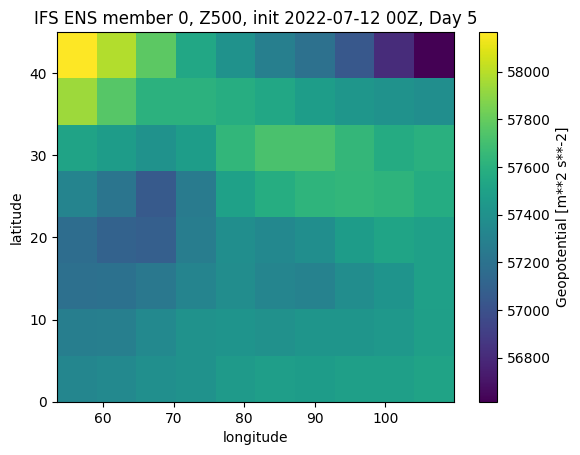

In [ ]:
import xarray as xr, numpy as np, matplotlib.pyplot as plt
S = {"token": "anon"}
ens = xr.open_zarr("gs://weatherbench2/datasets/ifs_ens/2018-2022-64x32_equiangular_conservative.zarr", storage_options=S, decode_timedelta=False)
print("levels:", ens.level.values, "| members:", ens.sizes["number"], "| lead index (hours):", ens.prediction_timedelta.values[:6], "...")
z = ens.geopotential.sel(level=500, time="2022-07-12T00").isel(prediction_timedelta=20, number=0).load()  # index 20 = 120 h = Day 5
z.transpose("latitude", "longitude").sel(latitude=slice(0, 45), longitude=slice(55, 110)).plot()
plt.title("IFS ENS member 0, Z500, init 2022-07-12 00Z, Day 5"); plt.show()


## Extract (resumable; re-run this cell if Colab disconnects)


In [ ]:
!python extract_region_stats.py --source ifs_ens --years 2020 2021 2022 --out /content/out


[open] gs://weatherbench2/datasets/ifs_ens/2018-2022-64x32_equiangular_conservative.zarr
[ens] 2192 inits, 50 members, 10 leads, grid 32x64
[era5] loading 2020-01-02 -> 2023-01-10
[climo] loading
[plan] 274 groups of 8 inits, checkpoint every 10
[done] /content/out/ifs_ens_z500_boxstats.parquet rows=219200 size=15.1 MB in 0.2 min


In [ ]:
import pandas as pd
df = pd.read_parquet("/content/out/ifs_ens_z500_boxstats.parquet")
print(df.shape)
print("median spread by lead:", df.groupby("lead_days").ens_std.median().round(0).to_dict())
print("median |mean-truth| by lead:", (df.ens_mean-df.truth).abs().groupby(df.lead_days).median().round(0).to_dict())


(219200, 15)
median spread by lead: {1: 22.0, 2: 32.0, 3: 42.0, 4: 52.0, 5: 63.0, 6: 73.0, 7: 84.0, 8: 95.0, 9: 106.0, 10: 115.0}
median |mean-truth| by lead: {1: 21.0, 2: 27.0, 3: 29.0, 4: 37.0, 5: 44.0, 6: 53.0, 7: 60.0, 8: 68.0, 9: 75.0, 10: 82.0}


In [ ]:
from google.colab import files
files.download("/content/out/ifs_ens_z500_boxstats.parquet")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional bonus (only if the above finished fast): WeatherNext 2 archive for cross-model validation


In [ ]:
# !python extract_region_stats.py --source fgn --years 2022 --out /content/out
# files.download('/content/out/fgn_z500_boxstats.parquet')
